# Data Types

[Official documentation](https://qualtran.readthedocs.io/en/latest/DataTypes.html)

### Introduction to Quantum Data: the Qubit

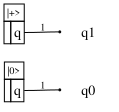

In [2]:
from qualtran import BloqBuilder
from qualtran.bloqs.basic_gates import ZeroState, PlusState

bb = BloqBuilder()
zero_q = bb.add(ZeroState())
plus_q = bb.add(PlusState())
cbloq = bb.finalize(q0=zero_q, q1=plus_q)

from qualtran.drawing import show_bloq
show_bloq(cbloq)

### Bloq Signatures and QBit

In [3]:
from qualtran import Signature, Register, QBit

signature = Signature([
    Register("arg1", QBit()),
    Register("arg2", QBit()),
])
print(signature.n_qubits())

2


### Quantum Data Types

In [4]:
from qualtran import QUInt

signature = Signature([
    Register("x", QUInt(32)),
    Register("y", QUInt(32)),
])
print(signature.n_qubits())

64


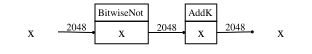

In [5]:
from qualtran.bloqs.arithmetic import Negate

# AddKは2の補数処理
negate = Negate(dtype=QUInt(2048))
show_bloq(negate.decompose_bloq())

### Splitting

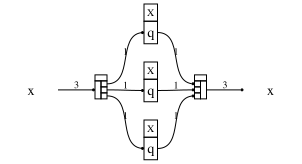

In [6]:
from qualtran.bloqs.basic_gates import XGate

dtype = QUInt(3)

bb = BloqBuilder()
x = bb.add_register_from_dtype("x", dtype)

# Split qubits
x_bits = bb.split(x)

# Apply XGate to each qubit
for i in range(len(x_bits)):
    x_bits[i] = bb.add(XGate(), q=x_bits[i])

# Join quibits
x = bb.join(x_bits, dtype)

cbloq = bb.finalize(x=x)
show_bloq(cbloq)

### Endianness

In [7]:
QUInt(8).to_bits(x=0x30)

[0, 0, 1, 1, 0, 0, 0, 0]

### Casting and QAny

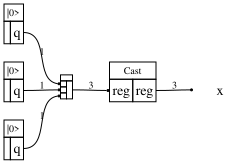

In [8]:
bb = BloqBuilder()

qs = [bb.add(ZeroState()) for _ in range(3)]

x = bb.join(qs)

from qualtran.bloqs.bookkeeping import Cast
from qualtran import QAny
x = bb.add(Cast(inp_dtype=QAny(3), out_dtype=QUInt(3)), reg=x)

cbloq = bb.finalize(x=x)
show_bloq(cbloq)

In [9]:
from qualtran import QDTypeCheckingSeverity, check_dtypes_consistent

print('same  ', check_dtypes_consistent(QUInt(3), QUInt(3)))
print('1bit  ', check_dtypes_consistent(QBit(), QAny(1)))
print('qany  ',
    check_dtypes_consistent(QAny(3), QUInt(3)),
    check_dtypes_consistent(QAny(3), QUInt(3), QDTypeCheckingSeverity.STRICT)
)
from qualtran import QInt
print('qint  ', 
    check_dtypes_consistent(QUInt(3), QInt(3)),
    check_dtypes_consistent(QUInt(3), QInt(3), QDTypeCheckingSeverity.STRICT)
)
print('diff  ', check_dtypes_consistent(QAny(3), QAny(4)))

same   True
1bit   True
qany   True False
qint   True False
diff   False


### QDType, CDType, and QCDType

In [10]:
from qualtran import QDType

print("QBit()   is QDType:", isinstance(QBit(), QDType),   "; num_qubits =", QBit().num_qubits)
print("QUInt(4) is QDType:", isinstance(QUInt(4), QDType), "; num_qubits =", QUInt(4).num_qubits)


QBit()   is QDType: True ; num_qubits = 1
QUInt(4) is QDType: True ; num_qubits = 4


In [11]:
from qualtran import QCDType, QDType, CDType, CBit

dtypes = [QBit(), QUInt(4), CBit()]

print(f"{'dtype':10} {'QCDType?':9s} {'QDType?':9s} {'CDType?':9s}"
      f"{'bits':>6s} {'qubits':>6s} {'cbits':>6s}"
     )
print("-"*60)
for dtype in dtypes:
    print(f"{dtype!s:10} {isinstance(dtype, QCDType)!s:9} {isinstance(dtype, QDType)!s:9} {isinstance(dtype, CDType)!s:9}"
          f"{dtype.num_bits:6d} {dtype.num_qubits:6d} {dtype.num_cbits:6d}"
         )

dtype      QCDType?  QDType?   CDType?    bits qubits  cbits
------------------------------------------------------------
QBit()     True      True      False         1      1      0
QUInt(4)   True      True      False         4      4      0
CBit()     True      False     True          1      0      1


### QGF